In [10]:
import pandas as pd

In [11]:
import pandas as pd

sales_of_company_x = pd.read_csv("monthly-sales-of-company-x-jan-6.csv")
robberies_in_boston = pd.read_csv("monthly-boston-armed-robberies-j.csv")
airlines_passengers = pd.read_csv("international-airline-passengers.csv")
mean_monthly_temp = pd.read_csv("mean-monthly-air-temperature-deg.csv")
dowjones_closing = pd.read_csv("weekly-closings-of-the-dowjones-.csv")
female_births = pd.read_csv("daily-total-female-births-in-cal.csv")

# Отображение графика

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
all_series = {
    "Monthly sales of company X": sales_of_company_x["Count"],
    "Monthly Boston armed robberies": robberies_in_boston["Count"],
    "International airline passengers: monthly totals in thousands": airlines_passengers.iloc[:, 1],
    "Mean monthly air temperature (Deg. F) Nottingham Castle": mean_monthly_temp["Deg"],
    "Weekly closings of the Dow-Jones industrial average": dowjones_closing["Close"],
    "Daily total female births in California": female_births["Count"]
}

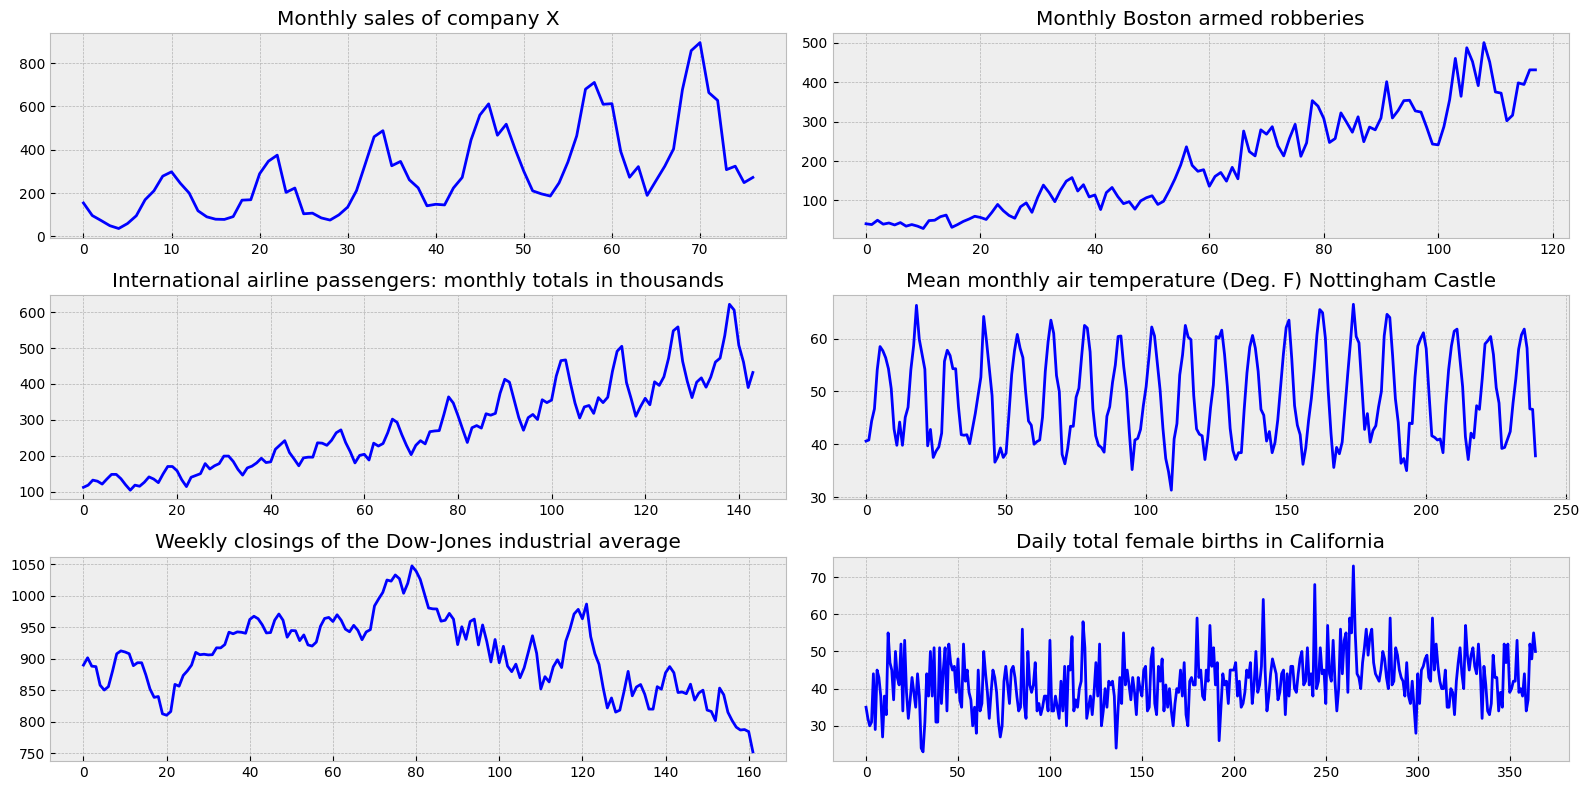

In [14]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 8))
    layout = (3, 2)
    for i, key in enumerate(all_series.keys()):
        x = i % 2
        y = int((i - x) / 2)
        
        ts_ax = plt.subplot2grid(layout, (y, x))
        all_series[key].plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key)
        
    plt.tight_layout()

# Ищем сезонность

In [15]:
def plot_ts_and_points(ts, start_point, step):
    new_series = [None for i in range(len(ts))]
    for i in range(len(ts)):
        pos = start_point + step * i
        if pos >= len(ts):
            break
        new_series[pos] = ts[pos]
    new_series = pd.Series(new_series)
    
    with plt.style.context('bmh'):
        plt.figure(figsize=(16, 8))
        ts_ax = plt.axes()
        ts.plot(ax=ts_ax, color='blue')
        new_series.plot(ax=ts_ax, style='ro')

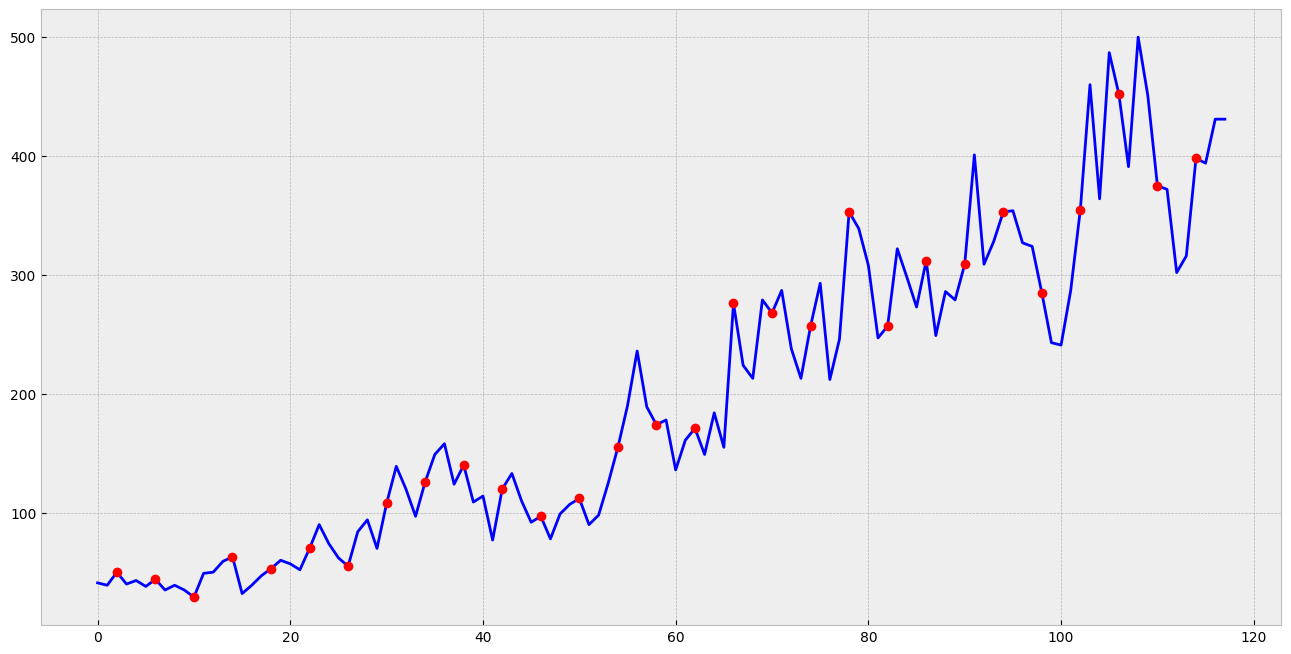

In [16]:
plot_ts_and_points(robberies_in_boston['Count'], 2, 4)

# Нормализуем дисперсию

In [17]:
from scipy.stats import boxcox

In [18]:
series = pd.Series(
    boxcox(all_series["International airline passengers: monthly totals in thousands"], 0),
    index=all_series["International airline passengers: monthly totals in thousands"].index
)

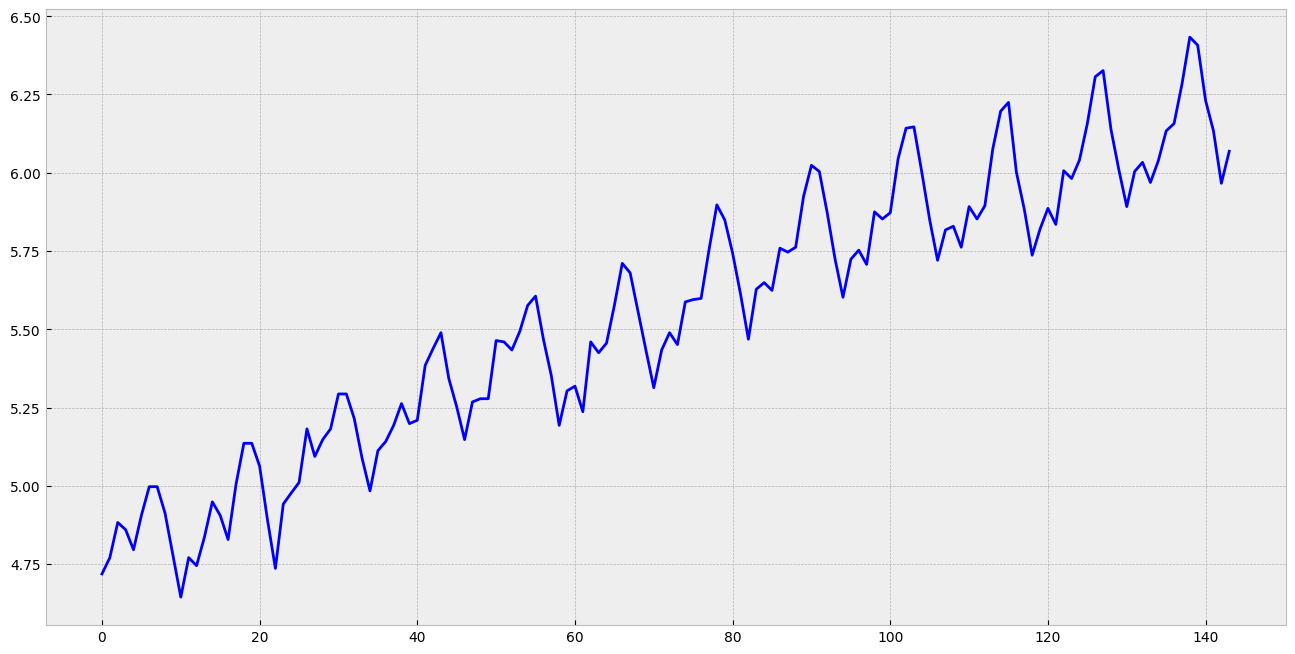

In [19]:
with plt.style.context('bmh'):
        plt.figure(figsize=(16, 8))
        plt.plot(series, color='blue')

# Дифференцируем 

In [20]:
import numpy as np

In [21]:
series = series.diff().dropna()

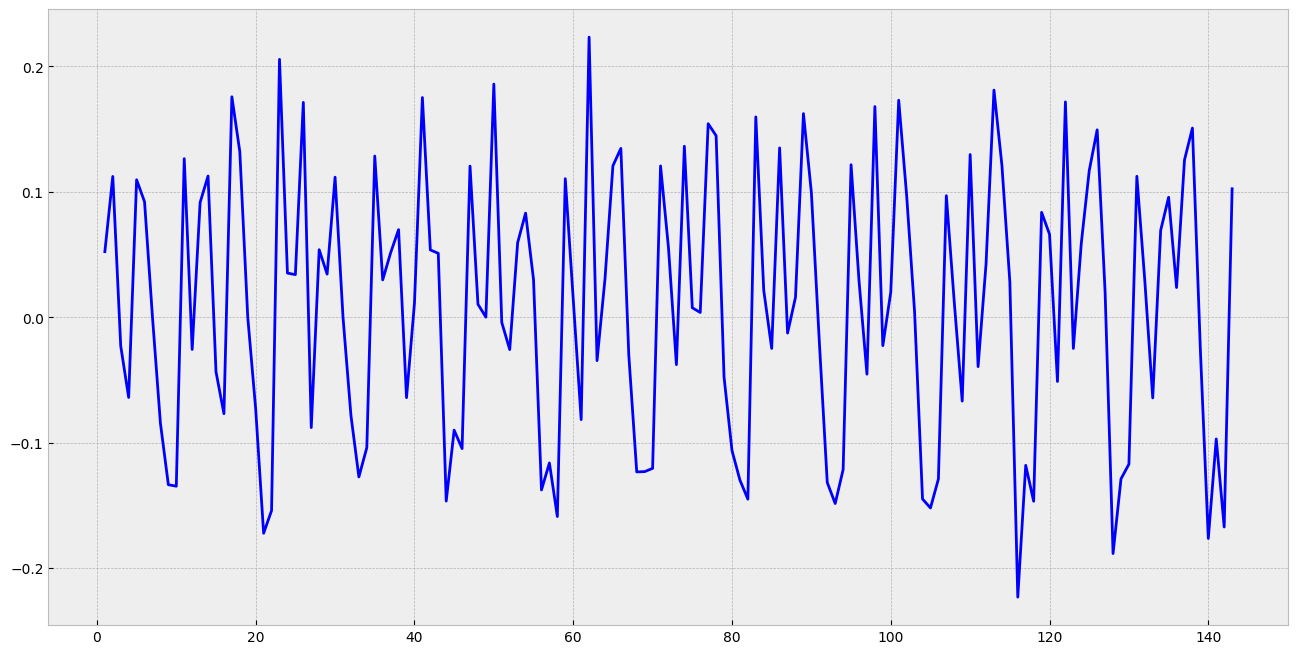

In [22]:
with plt.style.context('bmh'):
        plt.figure(figsize=(16, 8))
        plt.plot(series, color='blue')

In [23]:
series = series.diff(12).dropna()

# Тест Дики-Фуллера 

In [24]:
pip install statsmodels


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from statsmodels.tsa.stattools import adfuller

In [26]:
################
 # Dickey-Fuller
##################
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [27]:
test_stationarity(series)

Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64


In [28]:
test_stationarity(all_series["International airline passengers: monthly totals in thousands"])

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


# Коррелограммы

In [29]:
import statsmodels.api as sm
import statsmodels.tsa.api as smt

In [30]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (4, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)

        plt.tight_layout()
    return

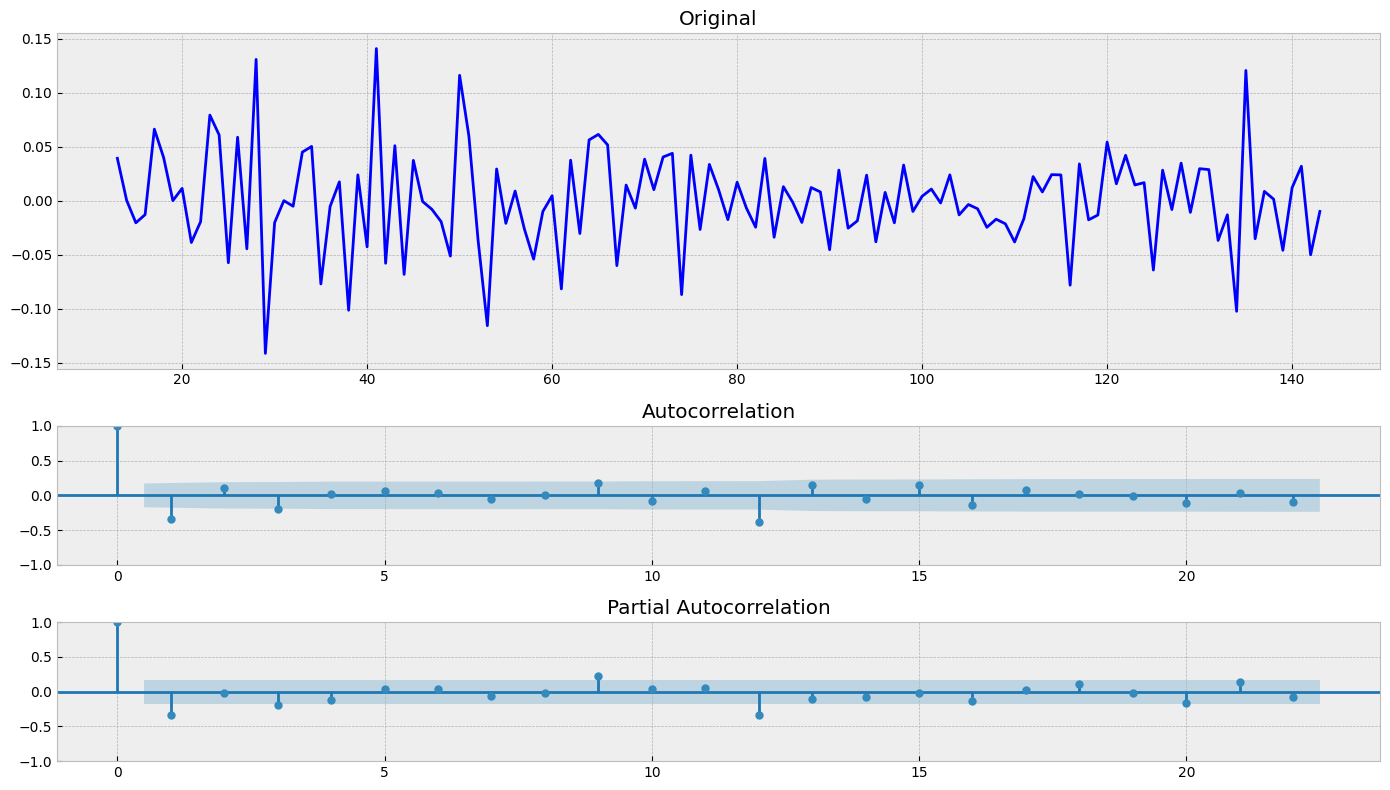

In [31]:
tsplot(series)

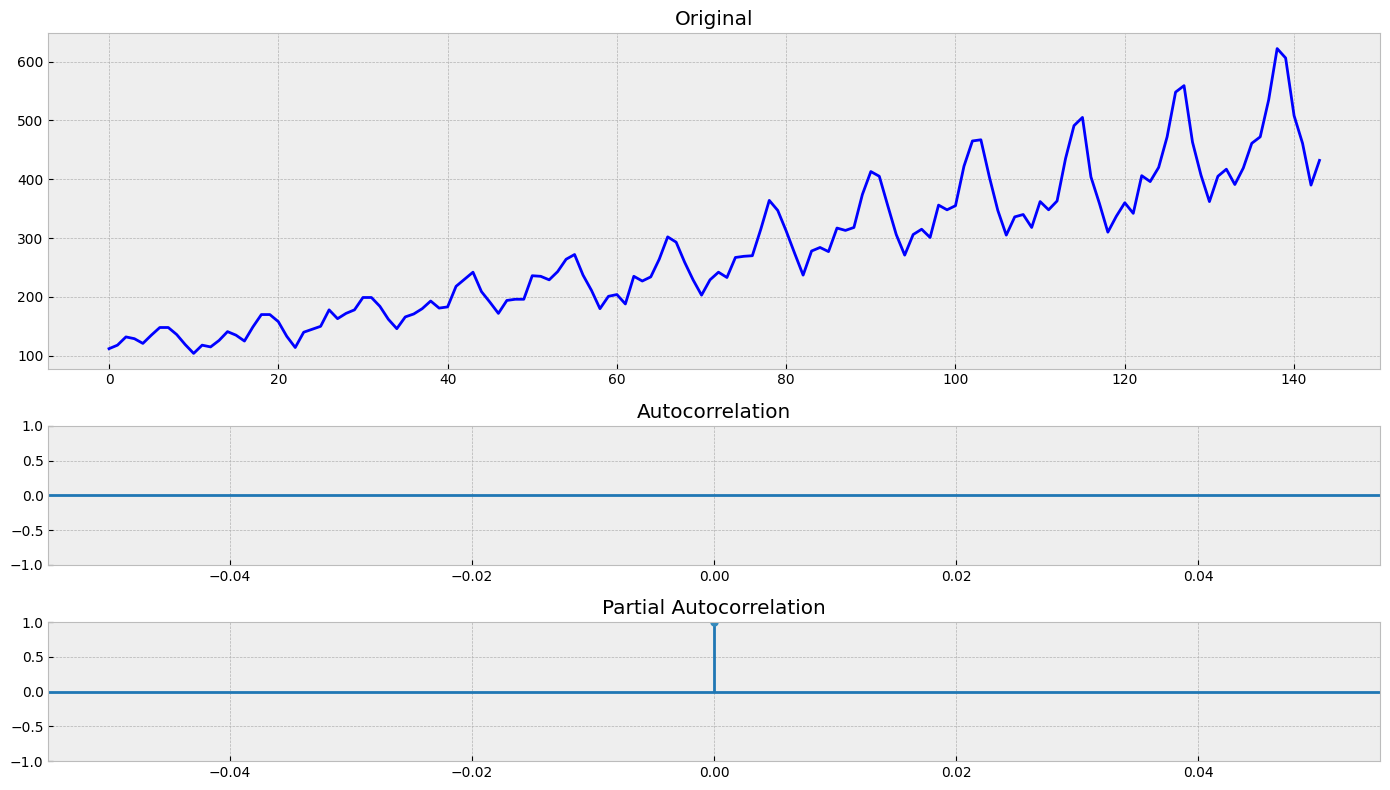

In [32]:
tsplot(all_series["International airline passengers: monthly totals in thousands"])

In [36]:
results = {}

In [39]:
series1 = sales_of_company_x["Count"]
series1 = np.log(series1)
series1 = series1.diff().dropna()
series1 = series1.diff(12).dropna()
results["Sales"] = series1

In [38]:
series2 = robberies_in_boston["Count"]
series2 = series2.diff().dropna()
results["Robberies"] = series2

In [40]:
series3 = airlines_passengers.iloc[:, 1]
series3 = pd.Series(boxcox(series3, 0))
series3 = series3.diff().dropna()
series3 = series3.diff(12).dropna()
results["Airlines"] = series3

In [41]:
series4 = mean_monthly_temp["Deg"]
series4 = series4.diff(12).dropna()
results["Temperature"] = series4

In [42]:
series5 = dowjones_closing["Close"]
series5 = np.log(series5)
series5 = series5.diff().dropna()
results["DowJones"] = series5

In [43]:
series6 = female_births["Count"]
series6 = series6.diff().dropna()
results["Births"] = series6


Sales
Results of Dickey-Fuller Test:
Test Statistic                 -2.316045
p-value                         0.166845
#Lags Used                     10.000000
Number of Observations Used    53.000000
Critical Value (1%)            -3.560242
Critical Value (5%)            -2.917850
Critical Value (10%)           -2.596796
dtype: float64

Robberies
Results of Dickey-Fuller Test:
Test Statistic                -7.428564e+00
p-value                        6.450795e-11
#Lags Used                     1.000000e+01
Number of Observations Used    1.060000e+02
Critical Value (1%)           -3.493602e+00
Critical Value (5%)           -2.889217e+00
Critical Value (10%)          -2.581533e+00
dtype: float64

Airlines
Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Cr

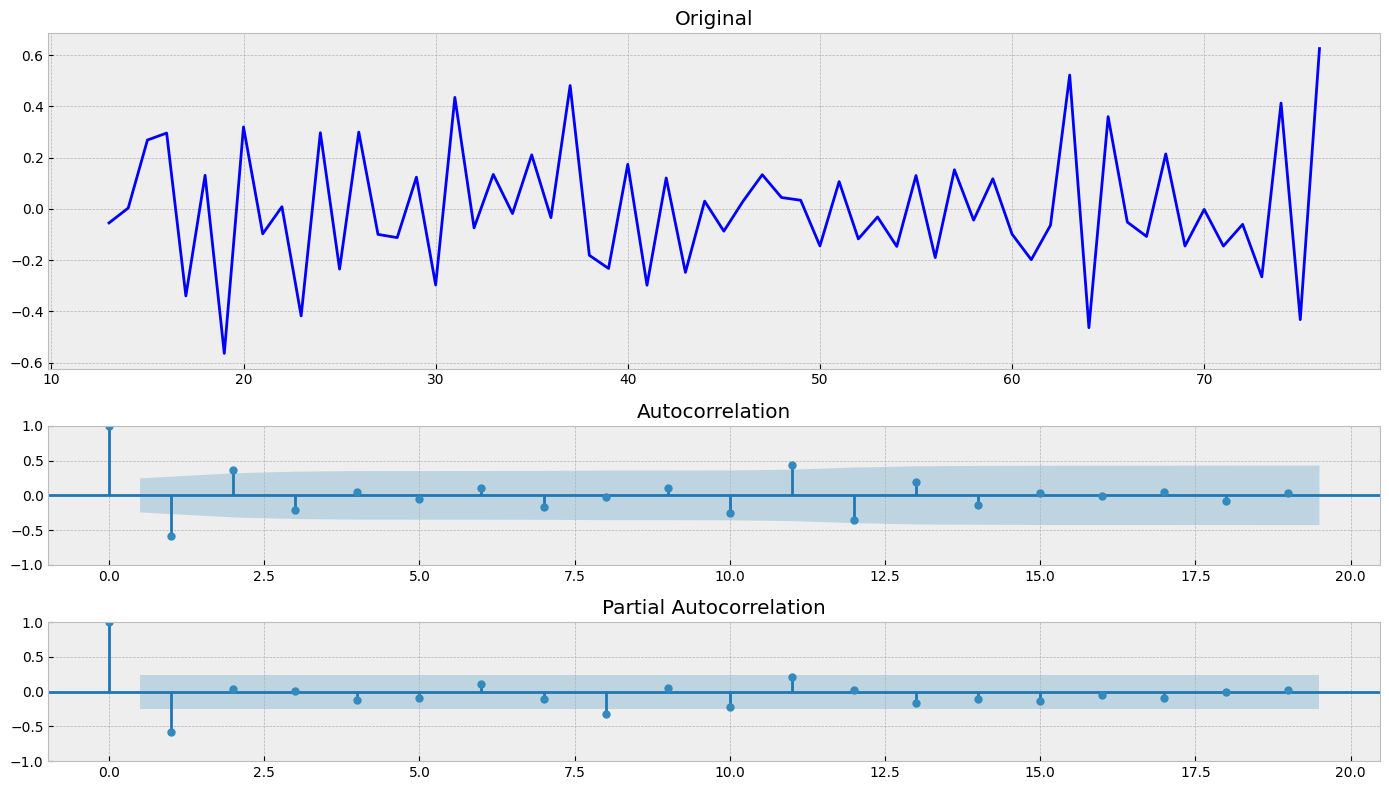

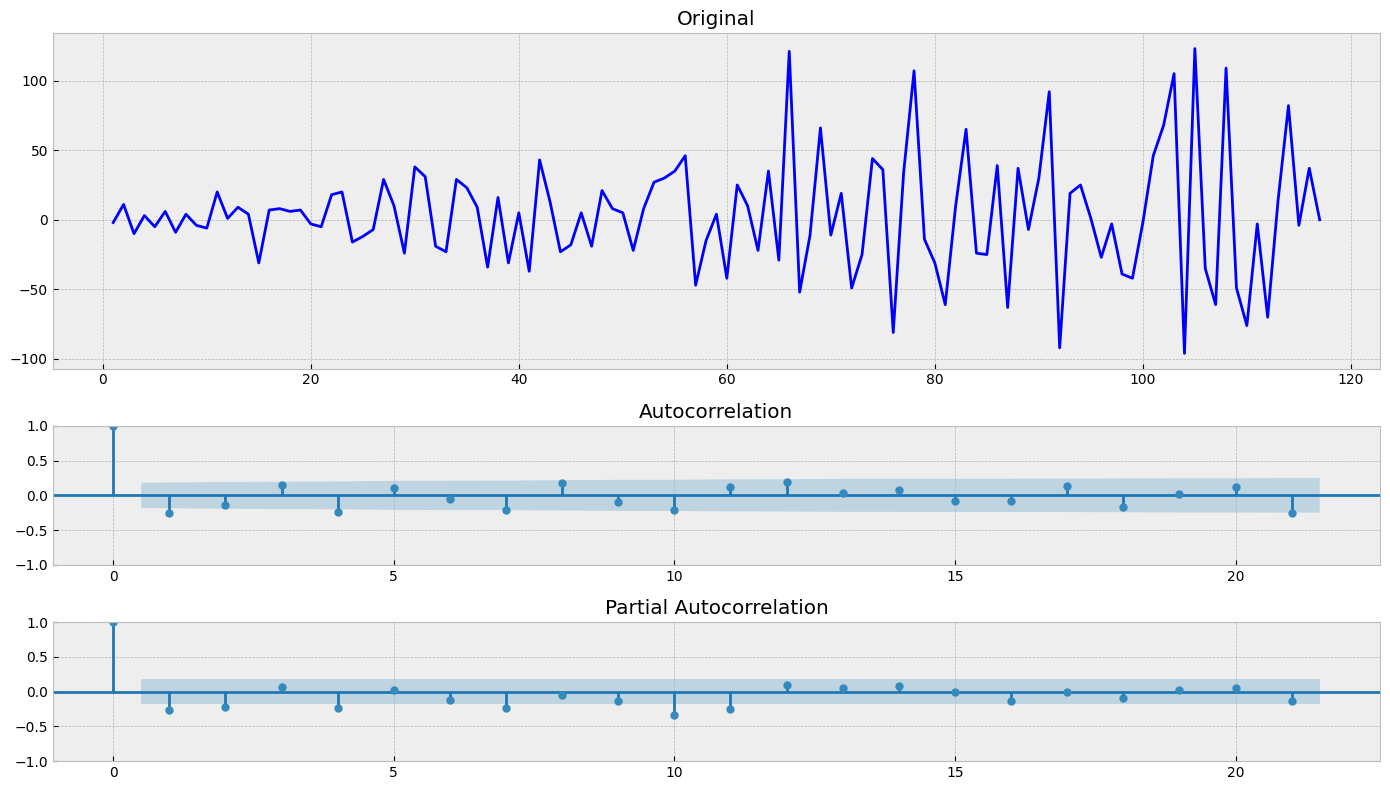

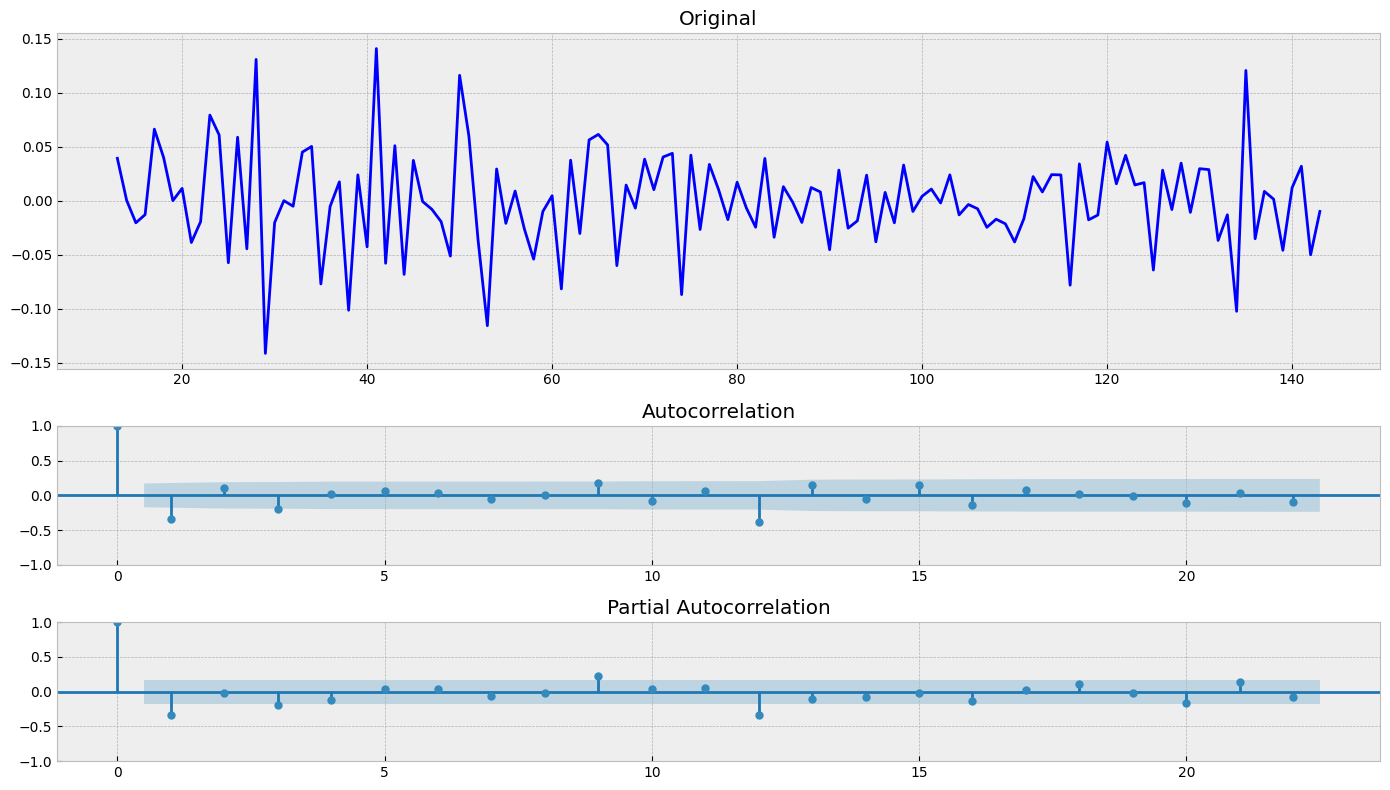

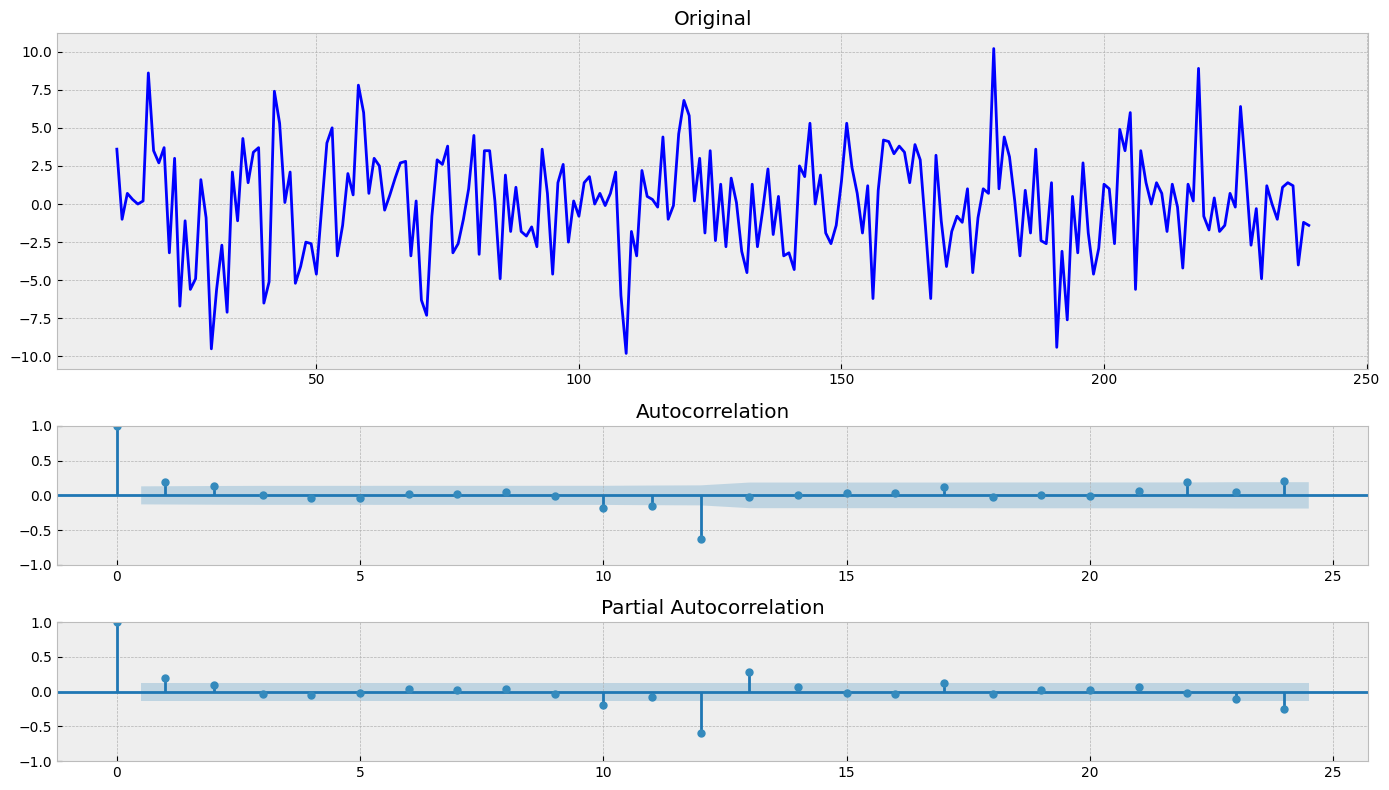

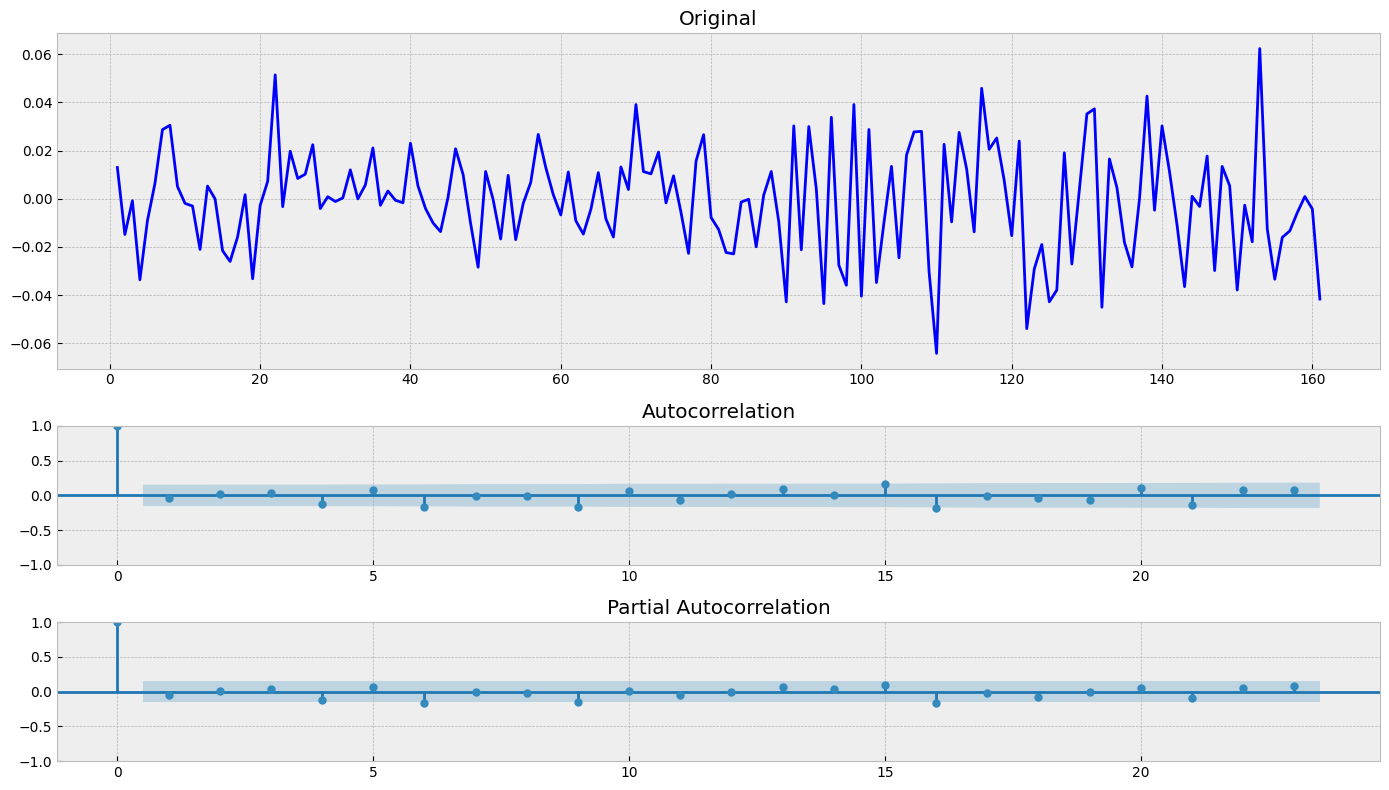

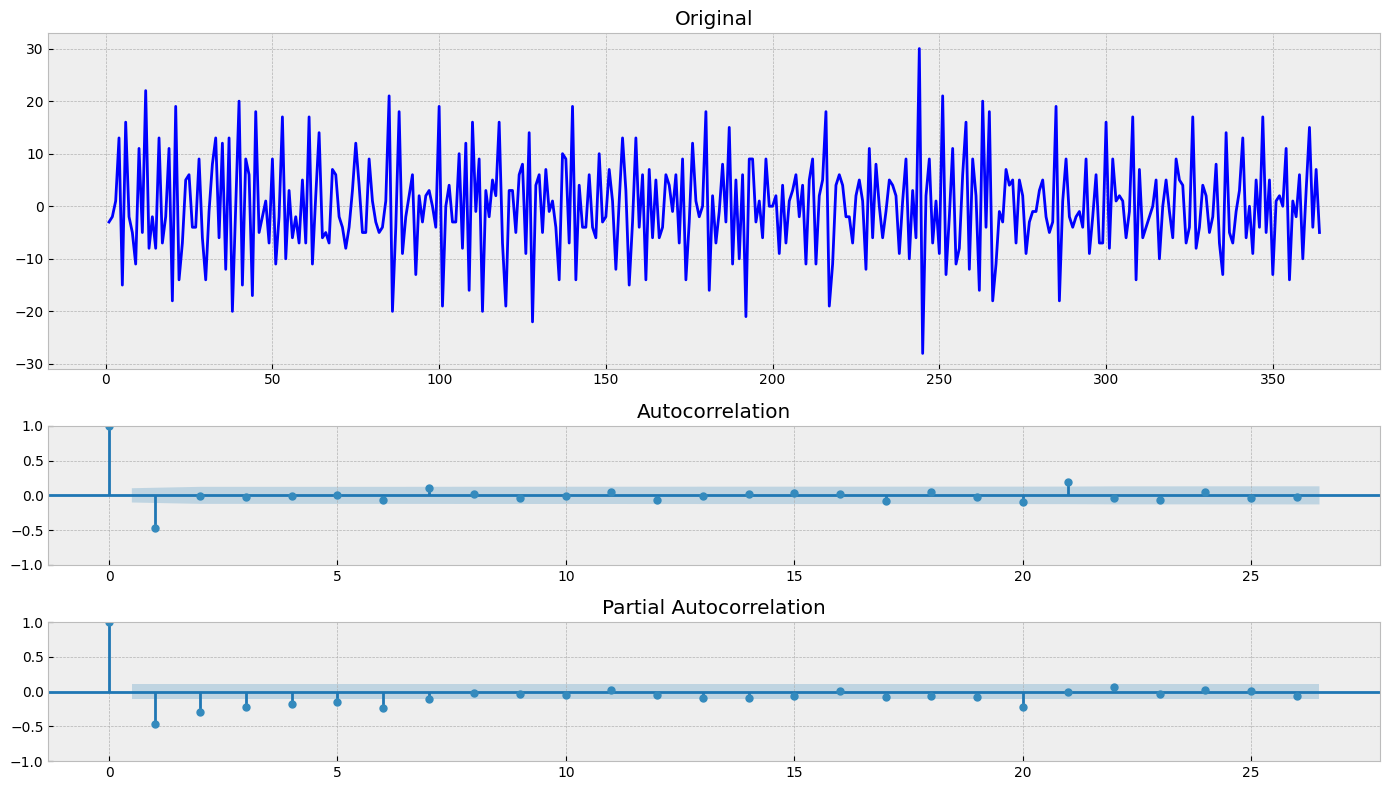

In [44]:
for name, series in results.items():
    print("\n==============================")
    print(name)
    print("==============================")
    
    tsplot(series)
    test_stationarity(series)

Все временные ряды были приведены к стационарному виду с помощью:
логарифмирования, дифференцирования и устранения сезонности.
Тест Дики-Фуллера подтверждает стационарность рядов.